# Chapter 16 - Error Fitting

This notebook shows a method of determining errors in a real accelerator by modelling a virtual twin. In the real accelerator, quadrupoles are "dithered" (strength slightly varied) and the closed orbit is recorded for each quad dithering. The result is dependent on the machine errors. We cannot directly measure the errors in real accelerator; we can only observe the BPM responses. Our model then optimizes the element errors in the model so that its responses align with the real responses we measured. 

The optimizer changes the model errors until the model BPM response agrees with the response from the simulated real machine. In this notebook the unknowns are quadrupole offsets and bend tilts, and the gradients are computed with finite differences.


In [ ]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()


In [4]:
using SciBmad
using CairoMakie
using Random
using Distributions
using FiniteDiff
using OptimizationLBFGSB
using ADTypes
using OptimizationOptimJL

set_theme!(theme_latexfonts())


## Load the Ring

We use the `RCSV5S0.jl` lattice in /lattices folder. The notebook first creates a simulated real machine from this lattice, then reloads the same lattice later to create the model machine used for fitting.


In [5]:
chapter16_lattice_path = joinpath(pwd(), "lattices", "chapter_16", "RCSV5S0.jl")
include(chapter16_lattice_path)

real_ring = ring
real_quads = real_ring.line[findall(x -> x.kind == "Quadrupole", real_ring.line)[1:2]]
real_bends = real_ring.line[findall(x -> x.kind == "SBend", real_ring.line)[1:2]]
real_bpms = real_ring.line[findall(x -> x.kind == "BPM", real_ring.line)[1:2]]

println("Loaded lattice: ", chapter16_lattice_path)
println("Quadrupoles used: ", [quad.name for quad in real_quads])
println("Bends used: ", [bend.name for bend in real_bends])
println("BPMs used: ", [bpm.name for bpm in real_bpms])


Loaded lattice: D:\Onedrive\Cornell\大一\Accelerator Physics\Ring_Design_Development\Ring_Design_Tutorial_SciBmad\lattices\chapter_16\RCSV5S0.jl
Quadrupoles used: ["qfs_6", "qds_1"]
Bends used: ["b0_1", "b0_2"]
BPMs used: ["bpm_1", "bpm_2"]


## 16.1 Helper Functions

These helper functions apply alignment-style errors to selected lattice elements. `apply_offsets!` assigns horizontal and vertical offsets to each element in a list, while `apply_tilts!` assigns a roll/tilt value. Both mutate the lattice elements in place, which is useful here because the optimizer repeatedly tests different error values.


In [6]:
function apply_offsets!(eles, offsets)
    @assert length(offsets) == 2 * length(eles) "Length of offsets does not correspond to length of eles"
    for i in 1:length(eles)
        eles[i].x_offset = offsets[2 * i - 1]
        eles[i].y_offset = offsets[2 * i]
    end
end

function apply_tilts!(eles, tilts)
    @assert length(tilts) == length(eles) "Length of tilts does not correspond to length of eles"
    for i in 1:length(eles)
        eles[i].tilt = tilts[i]
    end
end


apply_tilts! (generic function with 1 method)

## 16.2 Adding Errors and Tracking the Orbit



Now we apply the random error to the real ring we use. The quadrupoles are given horizontal and vertical offsets, while the bends are given small tilts. After a successful case is found, the applied errors are collected in `known_errors`. These values represent the hidden machine errors that the fitting procedure will try to recover later.

In [7]:
for seed in 123:200
    Random.seed!(seed)
    quad_offset_dist = truncated(Normal(0, 200e-6), -400e-6, 400e-6)
    bpm_offset_dist = truncated(Normal(0, 20e-6), -40e-6, 40e-6)
    bend_tilt_dist = truncated(Normal(0, 200e-6), -400e-6, 400e-6)

    quad_offsets = rand(quad_offset_dist, 2 * length(real_quads))
    bpm_offsets = quad_offsets # NOT YET ADDING BPM ERRORS .- rand(bpm_offset_dist, 2 * length(real_bpms))
    bend_tilts = rand(bend_tilt_dist, length(real_bends))

    apply_offsets!(real_quads, quad_offsets)
    apply_offsets!(real_bpms, bpm_offsets)
    apply_tilts!(real_bends, bend_tilts)

    try
        co_info = find_closed_orbit(ring)
        tw = twiss(ring; co_info=co_info)
        println("success! seed=$seed, tunes=$(tw.tunes)")
        break
    catch
        continue
    end
end

known_errors = zeros(2 * length(real_quads) + length(real_bends))
idx = 1
for quad in real_quads
    known_errors[idx] = quad.x_offset
    known_errors[idx + 1] = quad.y_offset
    idx += 2
end
for bend in real_bends
    known_errors[idx] = bend.tilt
    idx += 1
end

known_errors


success! seed=123, tunes=[0.13105464584617948, 0.21067972587310532, -0.02074364874971431]


6-element Vector{Float64}:
 -0.00012914613442079536
 -0.0002926502757777843
 -0.00032472074911721614
 -4.353302135670924e-5
  9.844913730503657e-5
  0.00019619596242482975

We then plot the orbit:

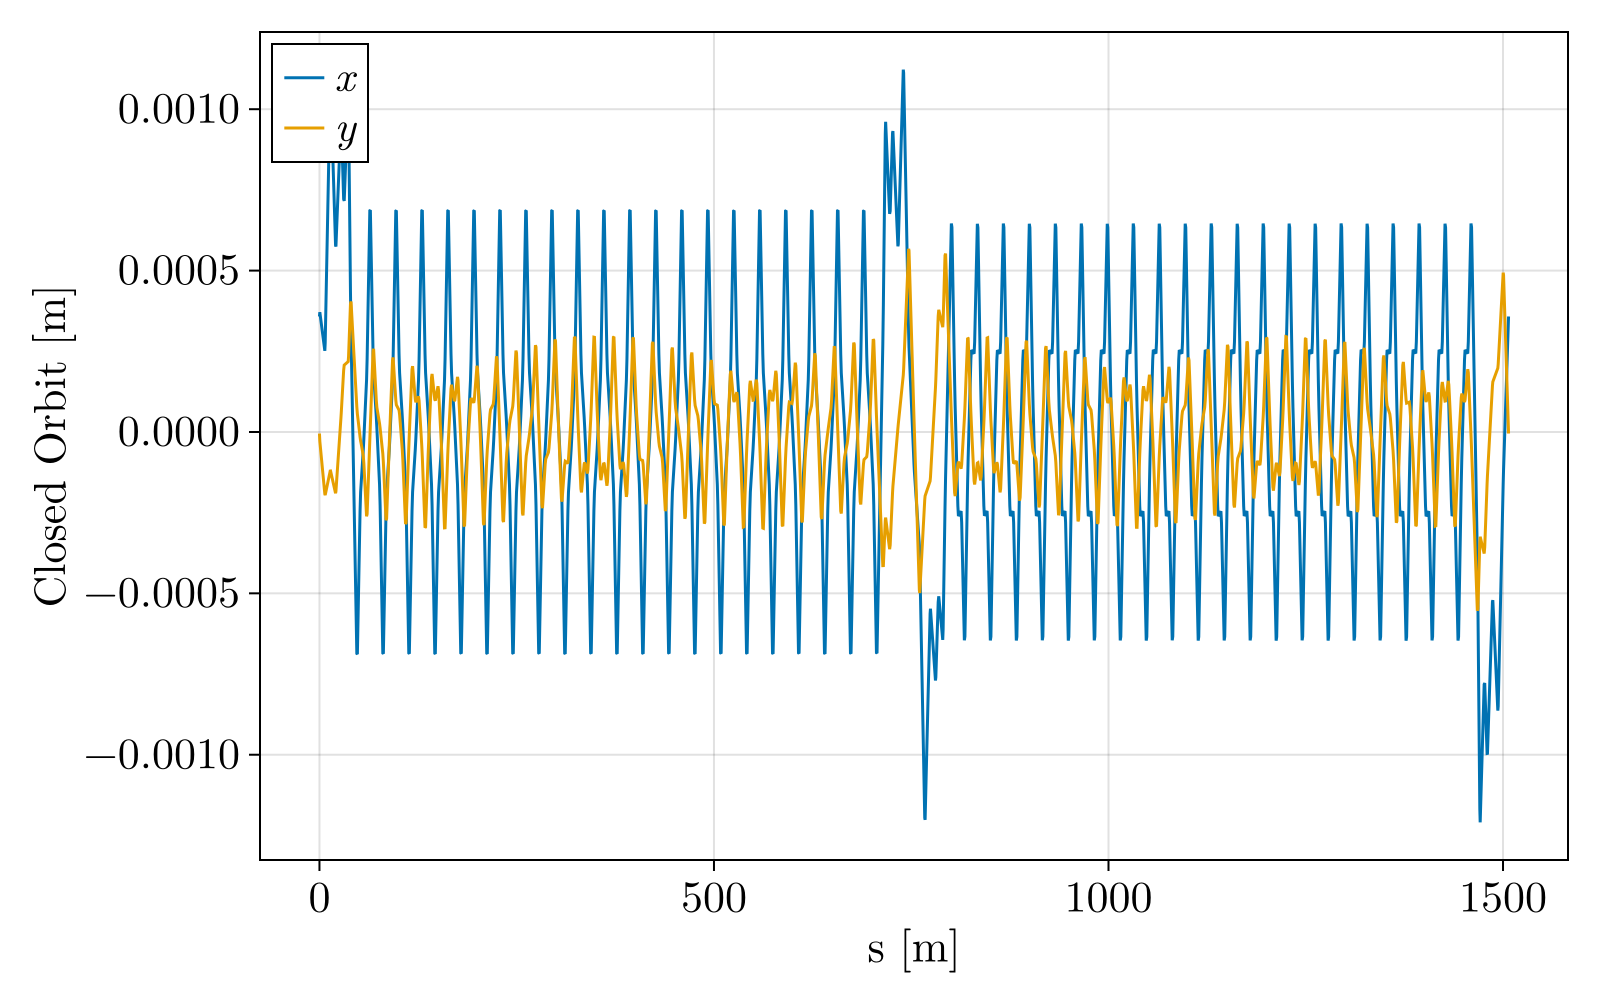

In [8]:
t = twiss(real_ring).table

f = Figure(fontsize=22, size=(800, 500))
ax = Axis(f[1, 1], xlabel="s [m]", ylabel="Closed Orbit [m]")
lines!(ax, t.s, t.orbit_x, label=L"x")
lines!(ax, t.s, t.orbit_y, label=L"y")
axislegend(position=:lt)
f


## 16.3 Dithering Quadrupoles
The fitting signal comes from repeatedly changing one quadrupole strength by a small amount and measuring the closed orbit at the BPMs. This mimics a machine-study measurement: the lattice is perturbed in a controlled way, and the BPM response carries information about the underlying alignment errors.

We first build the function that measures the closed orbit at a selected list of elements, which will usually be BPMs. It first finds the closed orbit of the full lattice, creates a bunch at that closed-orbit coordinate, and then tracks the bunch through the ring.

Whenever the tracking reaches one of the requested elements, the horizontal and vertical coordinates are stored in the output array. If the element itself has an offset, the offset is subtracted so that the recorded value represents the beam position relative to the local element center, as a BPM would report.


In [9]:
function closed_orbit_meas!(orbit, lattice::Beamline, eles::Vector{Beamlines.LineElement}; v0=zeros(6))
    @assert size(orbit, 1) == length(eles) "Size of orbit array not equal to eles array"
    orbit_x = view(orbit, :, 1)
    orbit_y = view(orbit, :, 2)
    co, __ = find_closed_orbit(lattice; v0=v0, coast=Val{false}())

    idx = 1
    b0 = Bunch(co; p_over_q_ref=lattice.p_over_q_ref, species=lattice.species_ref)
    for ele in lattice.line
        if ele in eles
            orbit_x[idx] = b0.coords.v[1]
            orbit_y[idx] = b0.coords.v[3]
            if !isnothing(ele.x_offset)
                orbit_x[idx] -= ele.x_offset
                orbit_y[idx] -= ele.y_offset
            end
            idx += 1
        end
        track!(b0, ele)
    end

    if lattice.line[end] in eles
        orbit_x[idx] = b0.coords.v[1]
        orbit_y[idx] = b0.coords.v[3]
        if !isnothing(lattice.line[end].x_offset)
            orbit_x[idx] -= lattice.line[end].x_offset
            orbit_y[idx] -= lattice.line[end].y_offset
        end
    end
    return orbit
end


closed_orbit_meas! (generic function with 1 method)

The next function performs the quadrupole dithering measurement. For each quadrupole in `quads`, it temporarily increases `Kn1` by a small amount, measures the closed orbit at the BPMs, and then restores the original quadrupole strength.

In [10]:
function dither!(bpm_meas, lattice, quads, bpms; dither=0.01, v0=zeros(6))
    @assert length(bpm_meas) == length(bpms) * 2 * length(quads)
    bpm_meast = reshape(bpm_meas, (length(bpms), 2 * length(quads)))
    for i in 1:length(quads)
        quad = quads[i]
        quad.Kn1 += dither
        closed_orbit_meas!(view(bpm_meast, :, 2 * i - 1:2 * i), lattice, bpms; v0=zeros(6))
        quad.Kn1 -= dither
    end
    return bpm_meas
end


dither! (generic function with 1 method)

Now we apply the dithering procedure to the simulated real machine. The resulting vector, `real_bpm_meas`, is the synthetic measurement data for this tutorial. Later, the optimizer will adjust errors in the model machine until its dithered BPM response matches this reference data.

In [11]:
real_bpm_meas = reshape(
    zeros(length(real_bpms), 2 * length(real_quads)),
    length(real_bpms) * 2 * length(real_quads),
)

dither!(real_bpm_meas, real_ring, real_quads, real_bpms)


8-element Vector{Float64}:
  0.00046349237117438455
  0.0005865843496545271
  0.00026312838709742015
 -0.00014699573708724578
  0.00047332683338454577
  0.0005905100802286842
  0.00025758062204022986
 -0.0001814464517414379

## 16.4 Define the Objective Function

Now we build the merit function for the optimizer. For a trial error vector $\mathbf{e}$, we apply those errors to the model lattice, perform the same quadrupole-dithering measurement, and compare the model BPM response with the BPM response measured from the real machine.

The objective function is the weighted sum of squared residuals:

$$
\chi^2(\mathbf{e}) =
\sum_i \left[
w \left( R_i^{\mathrm{model}}(\mathbf{e}) - R_i^{\mathrm{real}} \right)
\right]^2,
$$

where $R_i^{\mathrm{real}}$ is the dithered BPM response from the simulated real machine, and $R_i^{\mathrm{model}}(\mathbf{e})$ is the corresponding response from the model machine after applying the trial errors $\mathbf{e}$.

Minimizing this objective adjusts the model errors until the digital twin reproduces the measured orbit response of the real machine.

In the code below, `errors` is $\mathbf{e}$, `real_bpm_meas` is $R^{\mathrm{real}}$, and `res` is first filled with $R^{\mathrm{model}}(\mathbf{e})$ by `dither!`, then overwritten with the weighted residual.


In [12]:
function dither_objective(errors, p)
    ring = p[1]
    quads = p[2]
    bpms = p[3]
    bends = p[4]
    real_bpm_meas = p[5]
    res = p[6]
    weight = p[7]

    apply_offsets!(quads, view(errors, 1:2 * length(quads)))
    apply_offsets!(bpms, view(errors, 1:2 * length(quads)))
    apply_tilts!(bends, view(errors, (2 * length(quads) + 1):(2 * length(quads) + length(bends))))

    dither!(res, ring, quads, bpms)
    res .= weight .* (res .- real_bpm_meas)

    return sum(abs2, res)
end


dither_objective (generic function with 1 method)

## 16.5 Fitting Errors in the Model Machine



Here we create a separate model machine, starting again from the same design lattice. This model is the digital twin that we will calibrate. Unlike the simulated real machine, it does not initially contain the random errors added in Section 16.2.

In [13]:
include(chapter16_lattice_path)

model_ring = ring
model_quads = model_ring.line[findall(x -> x.kind == "Quadrupole", model_ring.line)[1:2]]
model_bends = model_ring.line[findall(x -> x.kind == "SBend", model_ring.line)[1:2]]
model_bpms = model_ring.line[findall(x -> x.kind == "BPM", model_ring.line)[1:2]]

res = rand(length(real_bpms) * 2 * length(real_quads))
errors = zeros(2 * length(real_quads) + length(real_bends))

p = (model_ring, model_quads, model_bpms, model_bends, real_bpm_meas, res, 10000)


(Beamline:
 species_ref = electron
 pc_ref = 7.499998259200281e8

  Index   Name     Kind         s [m]  
  1       qfs_6    Quadrupole   0
  2       qlo_1    Drift        0.47
  3       bpm_1    BPM          0.525
  4       clo_1    Drift        0.545
  5       cor_1    Kicker       0.583
  6       clo_2    Drift        0.84
  7       mqa5_1   Drift        0.878
  8       qlo_2    Drift        6.745
  9       qds_1    Quadrupole   6.8
  10      qlo_3    Drift        7.27
  11      bpm_2    BPM          7.325
  12      clo_3    Drift        7.345
  13      cor_2    Kicker       7.383
  14      clo_4    Drift        7.64
  15      mqa5_2   Drift        7.678
  16      qlo_4    Drift        13.545
  17      qfs_1    Quadrupole   13.6
  18      qlo_5    Drift        14.07
  19      bpm_3    BPM          14.125
  ⋮       ⋮        ⋮            ⋮

                       5368 rows omitted, Beamlines.LineElement[LineElement:
  UniversalParams                           BeamlineParams
   kind   

Before fitting, we can inspect the closed orbit of the uncalibrated model machine. Since this model has not yet been given the same errors as the simulated real machine, its orbit plot will generally not match the measured response from `real_ring`.

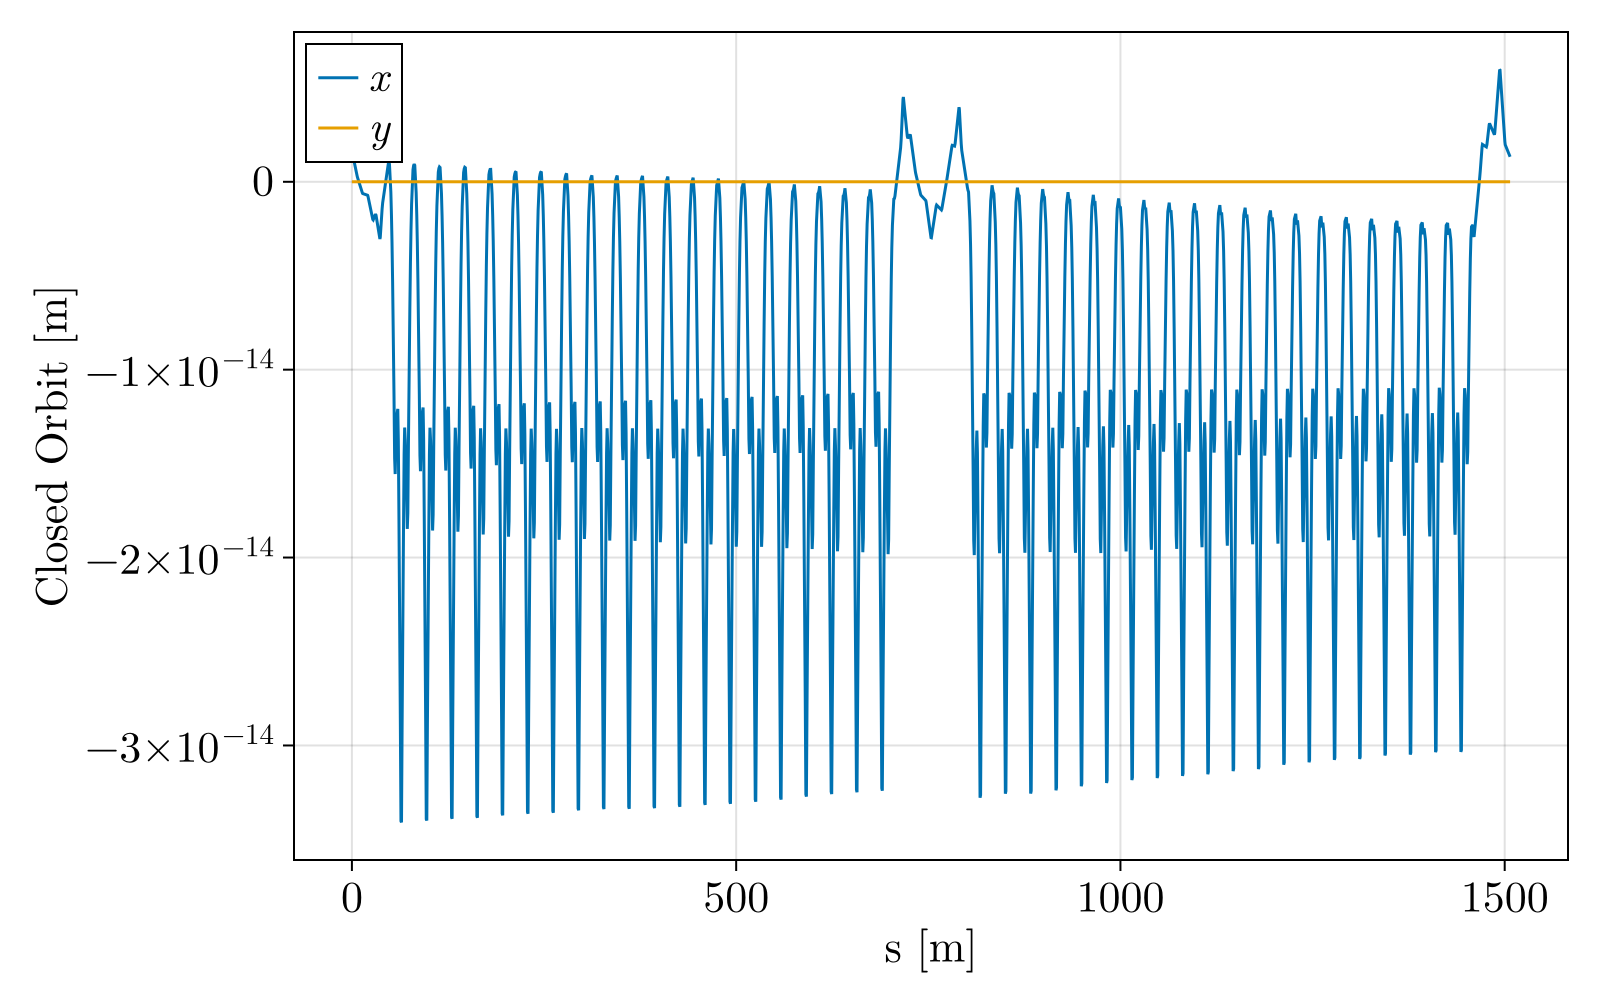

In [14]:
tm = twiss(model_ring).table

f = Figure(fontsize=22, size=(800, 500))
ax = Axis(f[1, 1], xlabel="s [m]", ylabel="Closed Orbit [m]")
lines!(ax, tm.s, tm.orbit_x, label=L"x")
lines!(ax, tm.s, tm.orbit_y, label=L"y")
axislegend(position=:lt)
f


Now run the optimizer that uses Auto Finite Difference to optimize the function `dither_objective` we built. The optimizer starts from the zero-error model and searches within the bounds $\pm 400~\mu\mathrm{m}$, or the corresponding small tilt range, for each error parameter. The `LBFGSB` method is used because it supports bound constraints. The fitted error vector is stored in `sol.u`.

In [16]:
optf = OptimizationFunction(dither_objective, AutoFiniteDiff())
prob = OptimizationProblem(
    optf,
    zero(errors),
    p;
    lb=-400e-6 .* ones(length(errors)),
    ub=400e-6 .* ones(length(errors)),
)

callback = (state, loss_val) -> begin
    print("
 Current solution = $(state.u), Objective = $(state.objective)")
    flush(stdout)
    false
end

sol = solve(prob, OptimizationLBFGSB.LBFGSB(); reltol=1e-16, callback=callback)



 Current solution = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Objective = 132.17617099674683
 Current solution = [0.0004, -0.0004, -0.0004, -0.0004, 0.0004, 0.0004], Objective = 1540.4889295496473
 Current solution = [5.965105546389371e-5, -5.965105546389371e-5, -5.965105546389371e-5, -5.965105546389371e-5, 5.965105546389371e-5, 5.965105546389371e-5], Objective = 65.15504762047658
 Current solution = [0.00011002426319972858, -0.00010060957888028503, -0.0001152197641151366, -3.354132731209886e-5, 8.846095354579644e-5, 8.783802235311514e-5], Objective = 10.533998653687128
 Current solution = [0.00012302427022776105, -0.00011744490890581028, -0.00013004438746319104, -2.659291486715029e-5, 9.738041169910133e-5, 9.665161158545134e-5], Objective = 7.348937318987855
 Current solution = [0.0001239124131801406, -0.00012539209135984384, -0.00013150173847911059, -2.6317602337711283e-5, 9.968703578983089e-5, 9.902062081863192e-5], Objective = 6.8885928909676855
 Current solution = [0.00012507196599507376, 

retcode: Success
u: 6-element Vector{Float64}:
 -0.00012976483615352995
 -0.00029311767434048755
 -0.00032521619774298407
 -4.491160525110539e-5
  0.00012871232642577347
  0.00012951228597965362

After the optimizer finishes, recompute the twiss table and plot the optimized orbit. This fitted model should now behave more like the simulated real machine. It is verified in the next section.

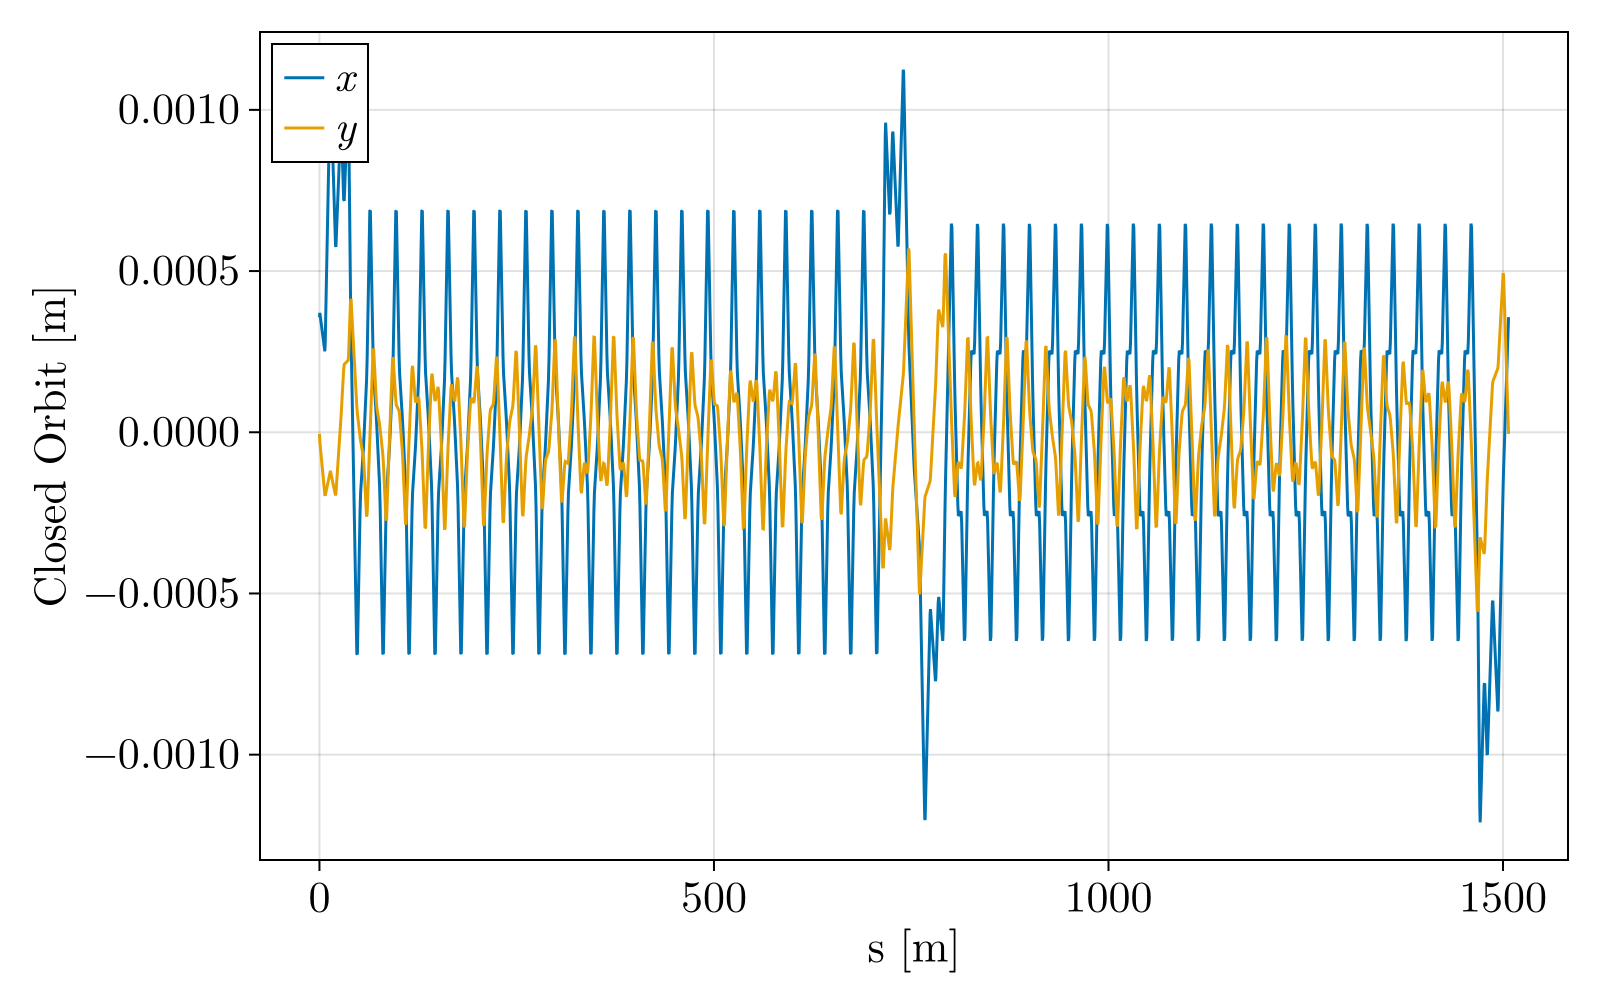

In [17]:
tm = twiss(model_ring).table

f = Figure(fontsize=22, size=(800, 500))
ax = Axis(f[1, 1], xlabel="s [m]", ylabel="Closed Orbit [m]")
lines!(ax, tm.s, tm.orbit_x, label=L"x")
lines!(ax, tm.s, tm.orbit_y, label=L"y")
axislegend(position=:lt)
f


## 16.6 Comparing the Fitted Model with the Real Machine

The tutorial keeps the randomly generated machine errors in `known_errors`, so we can directly compare the fitted model with the simulated truth. In a real accelerator these values would not be known; the comparison here is a diagnostic that shows whether the response fitting recovered the errors used to create the measured orbit data.

After the fit, the model orbit should also be close to the real-machine orbit. The cell below computes the differences of lattice element errors between the real machine and the model machine.

In [18]:
apply_offsets!(model_quads, view(sol.u, 1:2 * length(model_quads)))
apply_offsets!(model_bpms, view(sol.u, 1:2 * length(model_quads)))
apply_tilts!(
    model_bends,
    view(sol.u, (2 * length(model_quads) + 1):(2 * length(model_quads) + length(model_bends))),
)

println("Known errors:")
display(known_errors)

println("Fitted errors:")
display(sol.u)

println("Fitted - known:")
display(sol.u .- known_errors)


Known errors:


6-element Vector{Float64}:
 -0.00012914613442079536
 -0.0002926502757777843
 -0.00032472074911721614
 -4.353302135670924e-5
  9.844913730503657e-5
  0.00019619596242482975

Fitted errors:


6-element Vector{Float64}:
 -0.00012976483615352995
 -0.00029311767434048755
 -0.00032521619774298407
 -4.491160525110539e-5
  0.00012871232642577347
  0.00012951228597965362

Fitted - known:


6-element Vector{Float64}:
 -6.18701732734583e-7
 -4.67398562703275e-7
 -4.954486257679244e-7
 -1.3785838943961506e-6
  3.0263189120736898e-5
 -6.668367644517613e-5

Finally, plot the difference of the orbits between the real machine and the model machine.

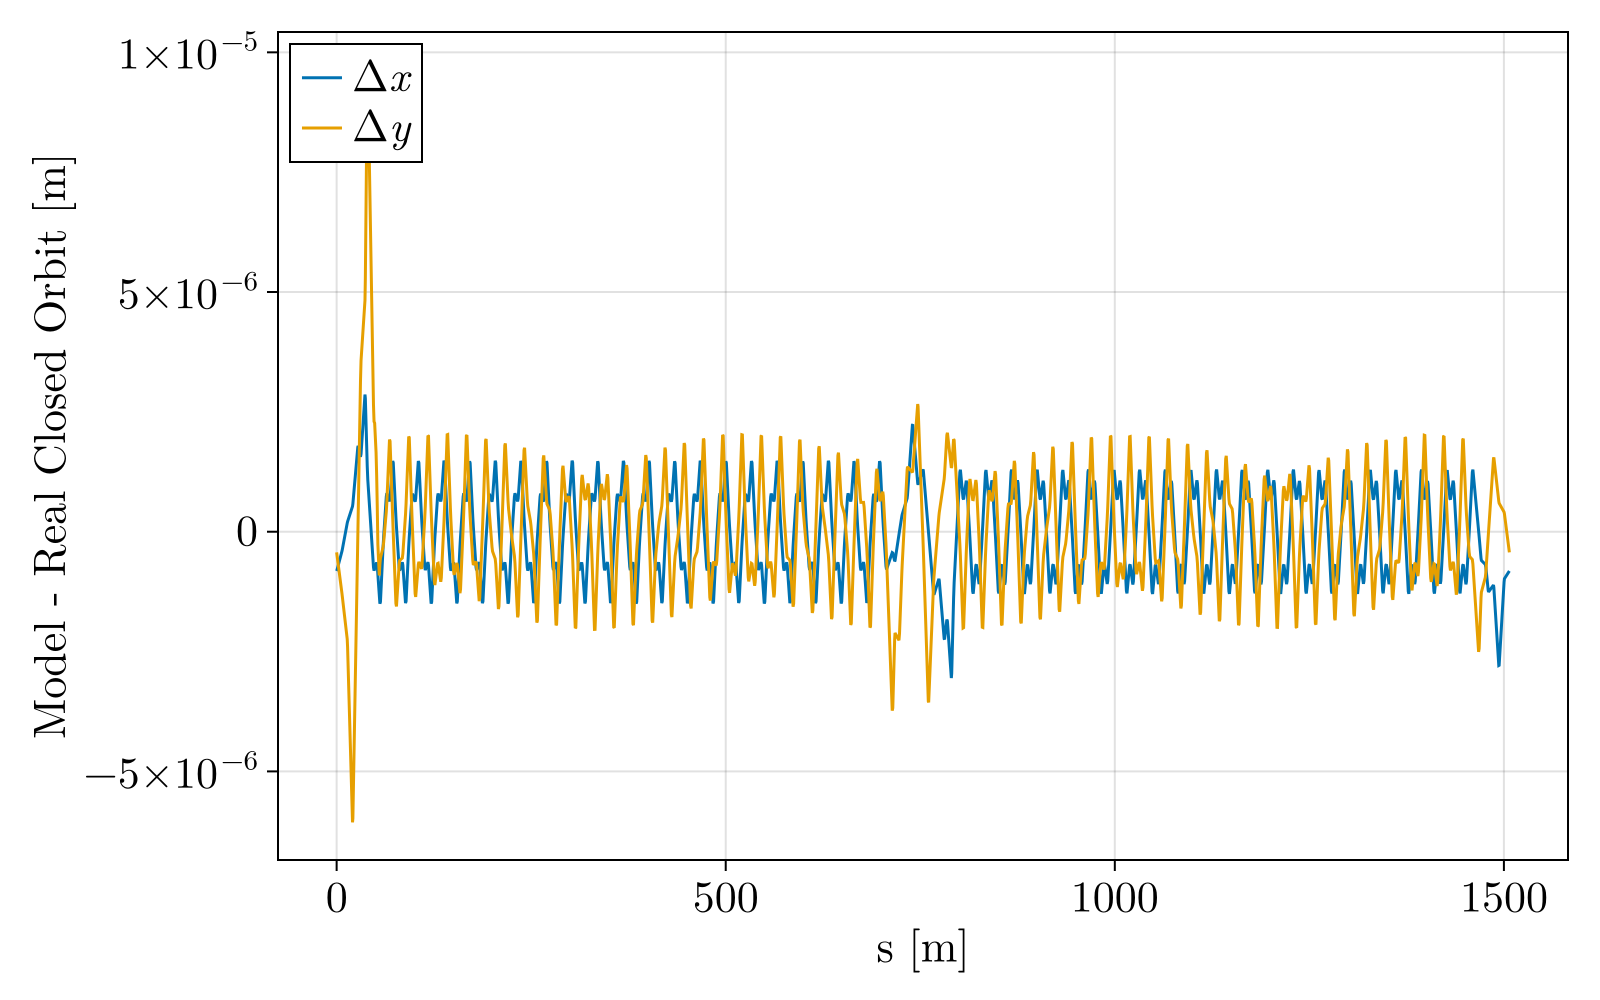

In [19]:
tm = twiss(model_ring).table
orbit_difference_x = tm.orbit_x .- t.orbit_x
orbit_difference_y = tm.orbit_y .- t.orbit_y

f = Figure(fontsize=22, size=(800, 500))
ax = Axis(f[1, 1], xlabel="s [m]", ylabel="Model - Real Closed Orbit [m]")
lines!(ax, tm.s, orbit_difference_x, label=L"\Delta x")
lines!(ax, tm.s, orbit_difference_y, label=L"\Delta y")
axislegend(position=:lt)
f
